# Experiment A - MPJPE vs network_period (Dataset-level)

Loads all generated CSVs across all sequences and computes:
- per-sequence MPJPE
- dataset-level MPJPE (weighted by number of frames)

Outputs:
- `results/summary/mpjpe_per_sequence.csv`
- `results/summary/mpjpe_table.csv`
- `plots/mpjpe_vs_network_period.png`
- `plots/mpjpe_vs_detection_rate.png`


In [36]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from datasets.utils import constants as ds_constants, parsing as ds_parsing


In [37]:
EXP_DIR = Path('/home/moveEnetFlow/experiments/expA_accuracy_vs_network_period')
RAW_DIR = EXP_DIR / 'results' / 'raw'
SUMMARY_DIR = EXP_DIR / 'results' / 'summary'
PLOTS_DIR = EXP_DIR / 'plots'

# Must match the --data_root used in run_experiment_a.sh
DATA_ROOT = Path('/data/new_scarfGNN_full/raw')

SUMMARY_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# Network periods to test (must match the PERIODS array in run_experiment_a.sh)
period_tokens = ["0.01", "0.02", "0.05", "0.1", "0.2", "0.5"]
period_values = [float(x) for x in period_tokens]
# period_token_to_val = {t: v for t, v in zip(period_tokens, period_values)}

print('DATA_ROOT:', DATA_ROOT)
print('RAW_DIR:', RAW_DIR)
print('Periods:', period_values)

DATA_ROOT: /data/new_scarfGNN_full/raw
RAW_DIR: /home/moveEnetFlow/experiments/expA_accuracy_vs_network_period/results/raw
Periods: [0.01, 0.02, 0.05, 0.1, 0.2, 0.5]


In [38]:
joint_names = list(ds_constants.HPECoreSkeleton.KEYPOINTS_MAP.keys())
assert len(joint_names) == 13, f'Expected 13 joints, got {len(joint_names)}'

def period_to_tag(period_token: str) -> str:
    """Convert period string to filename-safe tag (e.g., '0.01' -> '0p01')"""
    return period_token.replace('.', 'p')

def tag_to_period(tag: str) -> float:
    """Convert filename tag back to period value (e.g., '0p01' -> 0.01)"""
    return float(tag.replace('p', '.'))

def load_pred_eval_csv(csv_path: Path):
    """Load prediction CSV file and extract timestamps + joint coordinates.
    
    CSV format (evaluation format): [timestamp, latency, joint0_x, joint0_y, ..., joint12_x, joint12_y, velocities_if_requested]
    Returns: (timestamps, joints_array[N_frames, 13_joints, 2_coords])
    """
    arr = np.loadtxt(csv_path, delimiter=',', skiprows=1)
    if arr.ndim == 1:
        arr = arr[None, :]
    if arr.shape[1] < 28:
        raise ValueError(f'Unexpected CSV format for {csv_path}, columns={arr.shape[1]}')
    ts = arr[:, 0]
    joints = arr[:, 2:28].reshape(-1, 13, 2)
    return ts, joints

def interp_gt_to_pred_ts(gt_data, ts_pred: np.ndarray):
    """Interpolate ground truth skeleton data to match prediction timestamps.
    
    GT data comes at different sample rates than predictions, so we use linear 
    interpolation to align them for proper evaluation metrics calculation.
    """
    ts_gt_raw = np.asarray(gt_data['ts'])
    ts_gt = np.concatenate(([0.0], ts_gt_raw, [ts_gt_raw[-1] + 1.0]))
    joints_gt = np.zeros((len(ts_pred), 13, 2), dtype=np.float64)
    for j, joint in enumerate(joint_names):
        x_raw = gt_data[joint][:, 0]
        y_raw = gt_data[joint][:, 1]
        x = np.concatenate(([x_raw[0]], x_raw, [x_raw[-1]]))
        y = np.concatenate(([y_raw[0]], y_raw, [y_raw[-1]]))
        joints_gt[:, j, 0] = np.interp(ts_pred, ts_gt, x)
        joints_gt[:, j, 1] = np.interp(ts_pred, ts_gt, y)
    return joints_gt

def extract_metadata_from_name(csv_path: Path):
    """Parse CSV filename to extract experiment metadata.
    
    Expected format: 'sequence__method_np_period.csv'
    Returns: (sequence_key, method_name, network_period_seconds)
    """
    name = csv_path.name
    m = re.match(r'(.+)__(moveenet_ofk|moveenet_only)_np_(\d+p\d+|\d+)\.csv$', name)
    if not m:
        raise ValueError(f'Unrecognized filename format: {name}')
    seq_key, method_key, np_tag = m.groups()
    method = 'MoveEnet + OFK' if method_key == 'moveenet_ofk' else 'MoveEnet only'
    network_period_s = tag_to_period(np_tag)
    return seq_key, method, network_period_s

def gt_path_from_seq_key(seq_key: str):
    """Construct ground truth skeleton file path from sequence key.
    
    Sequence keys encode dataset-relative paths with '/' replaced by '__' for filename safety.
    Reconstructs the original path and appends standard GT skeleton location.
    """
    # seq_key stores DATA_ROOT-relative path with '/' encoded as '__'
    # (fallback for older names without '__' keeps single-level behavior)
    rel = seq_key.replace('__', '/') if '__' in seq_key else seq_key
    return DATA_ROOT / rel / 'ch0GT200Hzskeleton' / 'data.log'

In [46]:
csv_files = sorted(RAW_DIR.glob('np_*/*.csv'))
print(f'Found {len(csv_files)} prediction CSV files')
if len(csv_files) == 0:
    raise RuntimeError('No CSV files found. Run run_experiment_a.sh first.')

gt_cache = {}
rows = []

for csv_path in csv_files:
    seq_key, method, network_period_s = extract_metadata_from_name(csv_path)

    # Reconstruct GT path from sequence key
    gt_path = gt_path_from_seq_key(seq_key)
    if not gt_path.exists():
        print(f'Skipping (missing GT): {gt_path}')
        continue
    
    # Load GT data with caching to avoid redundant disk reads for sequences with multiple prediction files
    if gt_path not in gt_cache:
        gt_cache[gt_path] = ds_parsing.import_yarp_skeleton_data(gt_path, multi_channel=False)
    gt_data = gt_cache[gt_path]

    ts_pred, joints_pred = load_pred_eval_csv(csv_path)
    joints_gt = interp_gt_to_pred_ts(gt_data, ts_pred)

    err = np.linalg.norm(joints_pred - joints_gt, axis=2)  # [N,13] per-frame joint error (px)
    per_joint = err.mean(axis=0)                           # Avg error per joint across frames
    mpjpe_px = float(per_joint.mean())                     # Overall MPJPE across joints/frames

    n_samples = int(err.shape[0])                          # Number of logged pose rows (not event packets)
    rows.append({
        'sequence': seq_key,
        'method': method,
        'network_period_s': network_period_s,
        'detection_rate_hz': 1.0 / network_period_s,
        'n_samples': n_samples,                            # Pose samples in this CSV
        'sum_err_px': float(err.sum()),                    # Sum of all joint errors (px)
        'n_points': int(err.size),                         # Total joint measurements (n_samples * 13)
        'mpjpe_px': mpjpe_px,
        **{f'mpjpe_{joint}': float(per_joint[i]) for i, joint in enumerate(joint_names)}
    })

df_seq = pd.DataFrame(rows).sort_values(['network_period_s', 'sequence', 'method']).reset_index(drop=True)
print('Per-sequence rows:', len(df_seq))

# Show per-sequence table without the internal aggregation columns
hidden_cols = ['n_samples', 'sum_err_px', 'n_points']
visible_df = df_seq.drop(columns=hidden_cols, errors='ignore')
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(visible_df)


Found 180 prediction CSV files
Per-sequence rows: 180


Found 180 prediction CSV files
Per-sequence rows: 180


,sequence,method,network_period_s,detection_rate_hz,mpjpe_px,mpjpe_head,mpjpe_shoulder_right,mpjpe_shoulder_left,mpjpe_elbow_right,mpjpe_elbow_left,mpjpe_hip_left,mpjpe_hip_right,mpjpe_wrist_right,mpjpe_wrist_left,mpjpe_knee_right,mpjpe_knee_left,mpjpe_ankle_right,mpjpe_ankle_left
0,cam2_S1_Directions,MoveEnet + OFK,0.01,100.0,5.904527,4.123216,4.444748,3.934186,8.210614,5.863446,4.582922,3.800368,12.178151,11.964122,3.560946,3.124899,6.820639,4.150594
1,cam2_S1_Directions,MoveEnet only,0.01,100.0,5.901578,4.113017,4.430402,3.936039,8.199525,5.852453,4.578381,3.800923,12.183179,11.958286,3.566031,3.125440,6.824031,4.152802
2,cam2_S1_Discussion,MoveEnet + OFK,0.01,100.0,6.141833,3.260452,3.241221,4.276657,6.110000,6.855879,4.198309,4.155190,12.643520,13.299084,4.715042,4.864586,6.571458,5.652433
3,cam2_S1_Discussion,MoveEnet only,0.01,100.0,6.137041,3.247064,3.229099,4.270606,6.095246,6.848957,4.195535,4.155850,12.640192,13.296028,4.715015,4.864054,6.573448,5.650441
4,cam2_S1_Eating,MoveEnet + OFK,0.01,100.0,7.171565,3.846220,4.656456,3.913262,6.435360,7.042497,5.264063,5.369405,10.400500,12.125445,6.922899,7.777914,8.520372,10.955950
5,cam2_S1_Eating,MoveEnet only,0.01,100.0,7.169009,3.839556,4.646573,3.909343,6.436651,7.038360,5.261026,5.352691,10.415735,12.131315,6.919693,7.783758,8.510191,10.952232
6,cam2_S1_Greeting,MoveEnet + OFK,0.01,100.0,6.698637,5.066224,3.508153,4.363925,7.106457,7.494004,3.863337,4.074309,14.584722,14.099540,4.148223,4.384222,7.166877,7.222289
7,cam2_S1_Greeting,MoveEnet only,0.01,100.0,6.695651,5.067455,3.500978,4.363930,7.110170,7.496477,3.848124,4.074528,14.562921,14.101708,4.152416,4.379410,7.166233,7.219109
8,cam2_S1_Phoning,MoveEnet + OFK,0.01,100.0,7.253882,4.288453,5.633138,4.841633,7.107477,6.177649,5.160320,4.873067,12.036565,9.521077,7.172404,7.854732,9.177994,10.455960
9,cam2_S1_Phoning,MoveEnet only,0.01,100.0,7.247298,4.292689,5.634069,4.832826,7.098546,6.163167,5.145106,4.863489,12.039869,9.500080,7.174146,7.852809,9.174397,10.443681


In [57]:
if len(df_seq) == 0:
    raise RuntimeError('No valid sequence rows to aggregate.')

# Dataset-level aggregation per method + period (weighted by joint count)
agg = (
    df_seq.groupby(['network_period_s', 'detection_rate_hz', 'method'], as_index=False)
    .agg(sum_err_px=('sum_err_px', 'sum'), n_points=('n_points', 'sum'), n_samples=('n_samples', 'sum'))
)
agg['mpjpe_px'] = agg['sum_err_px'] / agg['n_points']
df_table = agg.sort_values(['network_period_s', 'method']).reset_index(drop=True)

per_seq_path = SUMMARY_DIR / 'mpjpe_per_sequence.csv'
table_path = SUMMARY_DIR / 'mpjpe_table.csv'
df_seq.to_csv(per_seq_path, index=False)
df_table.to_csv(table_path, index=False)

print('Saved:', per_seq_path)
print('Saved:', table_path)

# Wide table for quick view (hide network_period_s column in display only)
pivot = df_table.pivot(index=['network_period_s', 'detection_rate_hz'], columns='method', values='mpjpe_px').reset_index()
pivot.columns.name = None
# pivot_display = pivot.drop(columns=['casa'], errors='ignore')
display(pivot)


Saved: /home/moveEnetFlow/experiments/expA_accuracy_vs_network_period/results/summary/mpjpe_per_sequence.csv
Saved: /home/moveEnetFlow/experiments/expA_accuracy_vs_network_period/results/summary/mpjpe_table.csv


,network_period_s,detection_rate_hz,MoveEnet + OFK,MoveEnet only
0,0.01,100.0,7.108149,7.098118
1,0.02,50.0,7.151295,7.130953
2,0.05,20.0,7.236823,7.238206
3,0.10,10.0,7.437736,7.564053
4,0.20,5.0,7.978452,8.488784
5,0.50,2.0,10.071012,11.905663


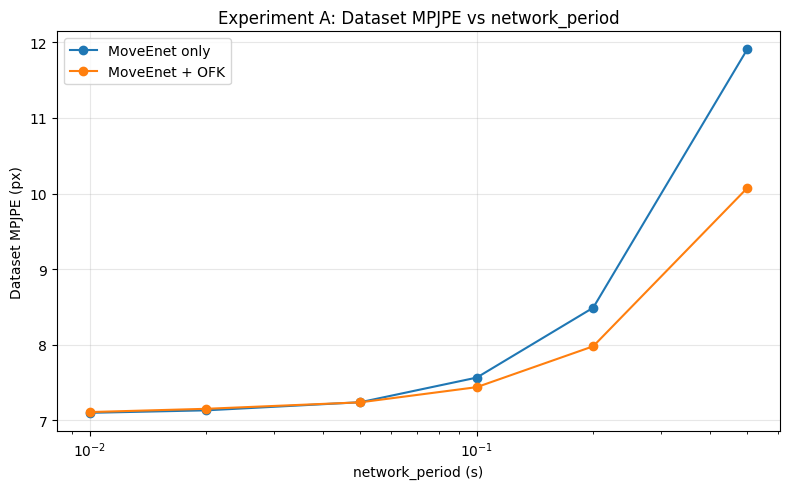

Saved: /home/moveEnetFlow/experiments/expA_accuracy_vs_network_period/plots/mpjpe_vs_network_period.png


In [60]:
plt.figure(figsize=(8, 5))
for method in ['MoveEnet only', 'MoveEnet + OFK']:
    d = df_table[df_table['method'] == method].sort_values('network_period_s')
    if len(d) == 0:
        continue
    plt.plot(d['network_period_s'], d['mpjpe_px'], marker='o', label=method)

plt.xscale('log')
plt.xlabel('network_period (s)')
plt.ylabel('Dataset MPJPE (px)')
plt.title('Experiment A: Dataset MPJPE vs network_period')
plt.grid(True, alpha=0.3)
plt.legend()
plot1 = PLOTS_DIR / 'mpjpe_vs_network_period.png'
plt.tight_layout()
plt.savefig(plot1, dpi=180)
plt.show()
print('Saved:', plot1)


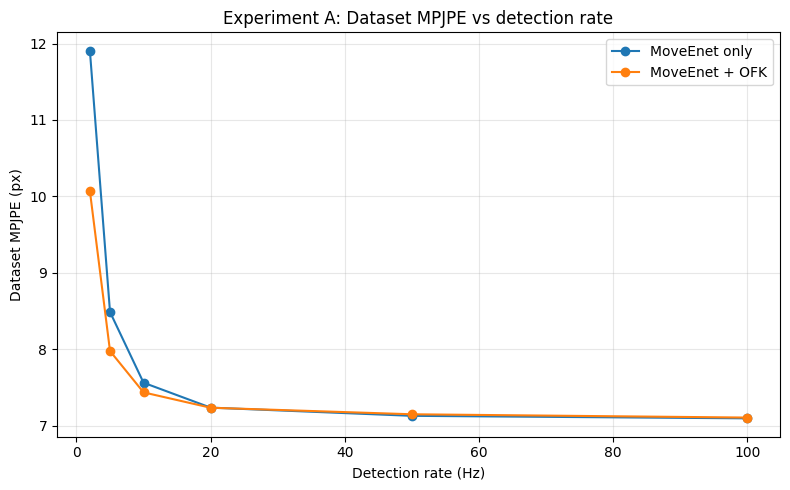

Saved: /home/moveEnetFlow/experiments/expA_accuracy_vs_network_period/plots/mpjpe_vs_detection_rate.png


: 

In [ ]:
plt.figure(figsize=(8, 5))
for method in ['MoveEnet only', 'MoveEnet + OFK']:
    d = df_table[df_table['method'] == method].sort_values('detection_rate_hz')
    if len(d) == 0:
        continue
    plt.plot(d['detection_rate_hz'], d['mpjpe_px'], marker='o', label=method)

plt.xlabel('Detection rate (Hz)')
plt.ylabel('Dataset MPJPE (px)')
plt.title('Experiment A: Dataset MPJPE vs detection rate')
plt.grid(True, alpha=0.3)
plt.legend()
plot2 = PLOTS_DIR / 'mpjpe_vs_detection_rate.png'
plt.tight_layout()
plt.savefig(plot2, dpi=180)
plt.show()
print('Saved:', plot2)
